# Coeficientes de Floquet

Vamos a armar un programa que pueda hacer una tabla de inestabilidades para cualquier tipo de potencial $V(\phi)$.

## Física

**$\LARGE{\text{Ecuaciones dinámicas}}$**

Durante recalentamiento tenemos que las ecuaciones de movimiento que rigen el background y las perturbaciones son las siguientes:

$$\ddot{\phi} + 3 \frac{\dot{a}}{a} \dot{\phi} + \frac{dV}{d\phi} = 0$$

$$\delta \ddot{\phi}_k + 3 \frac{\dot{a}}{a} ~ \delta \dot{\phi}_k + \left[ \frac{k^2}{a^2} + \frac{d^2 V}{d\phi^2} \right] \delta \phi_k = 0$$

$$\ddot{\chi}_k + 3 \frac{\dot{a}}{a} \dot{\chi}_k + \left( \frac{k^2}{a^2} + g^2 \phi^2 \right) \chi_k = 0$$

$$\ddot{a} + \frac{a}{3 m_p^2} \left[ \dot{\phi}^2 - V (\phi) \right] = 0$$

Y para hacer un análisis de tipo Floquet necesitamos que el universo no se expanda lo que implica tomar $a = 1 = cte$ y $H = 0$, por tanto tenemos que en ese caso las ecuaciones nos quedan de la siguiente forma:

$$\ddot{\phi} + \frac{dV}{d\phi}= 0$$

$$\delta \ddot{\phi}_k + \left( k^2 + \frac{d^2 V}{d\phi^2} \right) \delta \phi_k = 0$$

$$\ddot{\chi}_k + \left( k^2 + g^2 \phi^2 \right) \chi_k = 0$$

**$\LARGE{\text{Conservación de la energía}}$**

Para hacer un análisis de tipo Floquet necesitamos conocer el período de oscilación del inflatón y para ello usaremos la conservación de la energía, la cual surge de plantear que el universo no se expande:

- A tiempo inicial para reheating tenemos 

$$E = \frac{\dot{\phi}_0^2}{2} + V(\phi_0)$$

- Y para un tiempo arbitrario tenemos 

$$E = \frac{\dot{\phi}^2}{2} + V(\phi)$$

**$\LARGE{\text{Período de oscilación del infaltón}}$**

Despejando de la última ecuación tenemos

$$\dot{\phi} = \sqrt{2 \left[E - V \left( \phi \right) \right]}$$

$$\frac{d\phi}{dt} = \sqrt{2 \left[E - V \left( \phi \right) \right]}$$

$$dt = \frac{d\phi}{\sqrt{2 \left[E - V \left( \phi \right) \right]}}$$

$$\int_0^T dt = \int_{-\phi_0}^{\phi_0} \frac{d\phi}{\sqrt{2 \left[E - V \left( \phi \right) \right]}}$$

$$T = \frac{1}{\sqrt{2 E}} \int_{-\phi_0}^{\phi_0} \frac{d\phi}{\displaystyle \sqrt{1- \frac{V \left( \phi \right)}{E}}}$$

**$\LARGE{m^2 \phi^2}$**

Veamos cuánto vale para $V(\phi) = m^2 \phi^2$ para verificar que da una constante

$$T = \frac{1}{\sqrt{2 E}} \int_{-\phi_0}^{\phi_0} \frac{d\phi}{\displaystyle \sqrt{1- \frac{m^2 \phi^2}{E}}}$$

- Definimos $\displaystyle \sin (u) = \frac{m \phi}{\sqrt{E}}$ y $\displaystyle \cos (u) ~ du = \frac{m}{\sqrt{E}} ~ d\phi$, tal que la integral nos queda de la siguiente forma

$$T = \frac{1}{\sqrt{2} m} \int_{-\arcsin \left( \frac{m \phi_0}{\sqrt{E}} \right)}^{\arcsin \left( \frac{m \phi_0}{\sqrt{E}} \right)} \frac{\cos u ~ du}{\displaystyle \sqrt{1- \sin^2 u}}$$

$$T = \frac{1}{\sqrt{2} m} \int_{-\arcsin \left( \frac{m \phi_0}{\sqrt{E}} \right)}^{\arcsin \left( \frac{m \phi_0}{\sqrt{E}} \right)} \frac{\cos u ~ du}{\displaystyle \cos u}$$

$$T = \frac{1}{\sqrt{2} m} \int_{-\arcsin \left( \frac{m \phi_0}{\sqrt{E}} \right)}^{\arcsin \left( \frac{m \phi_0}{\sqrt{E}} \right)} du$$

$$T = \frac{2}{\sqrt{2} m} \arcsin \left( \frac{m \phi_0}{\sqrt{E}} \right)$$

$$T = \frac{\sqrt{2}}{m} \arcsin \left( \frac{m \phi_0}{\sqrt{E}} \right)$$

## Librerías

In [4]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

## $m^2 \phi^2$

### Funciones

In [5]:
# Función para armarse la matriz de monodromía y calcular los coeficientes de Floquet
def calculate_mu_k(k, g, y0, Tosc):
    phi0, phi_dot0 = y0

    def pert(t, y, k, g):
        phi, phi_dot, chi_k, chi_dot_k = y
        phi_ddot = - phi
        chi_ddot_k = - (k + g**2 * phi) * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

    t_span = (0, Tosc)

    sol1 = solve_ivp(pert, t_span, [phi0, phi_dot0, 1.0, 0.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, g))
    y_final1 = sol1.y[:, -1]

    sol2 = solve_ivp(pert, t_span, [phi0, phi_dot0, 0.0, 1.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, g))
    y_final2 = sol2.y[:, -1]

    M = np.array([
        [y_final1[0], y_final2[0]],
        [y_final1[1], y_final2[1]]
    ])

    tr_M = np.trace(M)
    argument = np.abs(tr_M / 2.0)

    if argument > 1.0:
        mu = np.arccosh(argument) / Tosc
        return mu
    else:
        return 0.0
    
# Función para calcular el período de oscilación del inflatón
def oscilation(E, phi0, g):
    def integrand(phi, g):
        V = 0.5 * phi**2
        return 1.0 / np.sqrt(2 * (E - V))
    integral, _ = quad(integrand, -phi0, phi0, args=(g,))
    Tosc = np.sqrt(2) * integral
    return Tosc

100%|██████████| 100/100 [01:28<00:00,  1.13it/s]
/home/tomy/miniconda3/lib/python3.12/site-packages/matplotlib/contour.py:1371: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/home/tomy/miniconda3/lib/python3.12/site-packages/matplotlib/contour.py:1372: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/home/tomy/miniconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


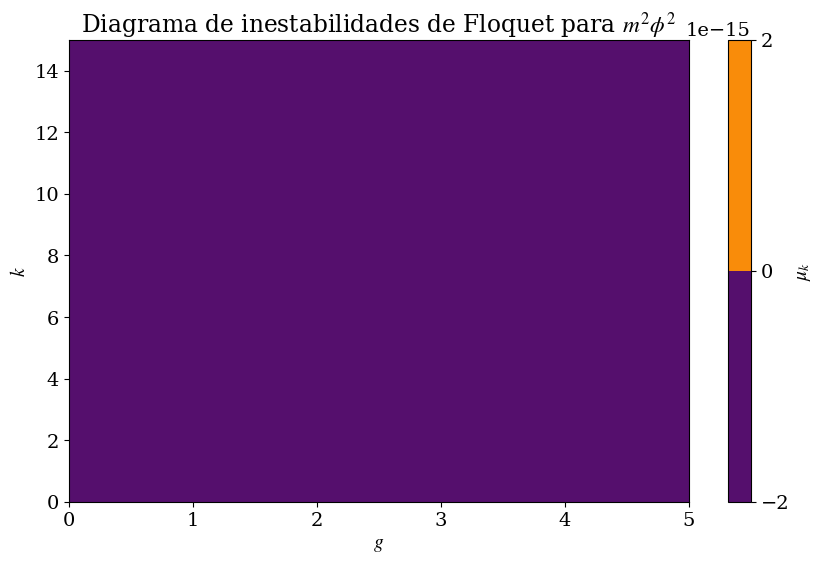

In [7]:
# Calculemos una tabla de inestabilidades de Mathieu para ver si funciona el código

phi0 = 1
phi_dot0 = 0
y0 = (phi0, phi_dot0)
E = 0.5 * phi_dot0**2 + 0.5 * phi0**2

qs = np.linspace(0, 5, 100)
Aks = np.linspace(0, 15, 100)
q, Ak = np.meshgrid(qs, Aks)
mu = np.zeros((len(Aks), len(qs)), dtype=complex)

for i, g in enumerate(tqdm(qs)):
    Tosc = oscilation(E, phi0, g)
    for j, k in enumerate(Aks):
        mu[j, i] = np.real(calculate_mu_k(k, g, y0, Tosc))

# Ahora grafiquemos el diagrama de inestabilidades
plt.figure(figsize=(10, 6))
plt.contourf(qs, Aks, mu, levels=100, cmap='inferno')
plt.colorbar(label=r'$\mu_k$')
plt.xlabel(r'$g$')
plt.ylabel(r'$k$')
plt.title(r'Diagrama de inestabilidades de Floquet para $m^2 \phi^2$')
plt.show()

In [19]:
def mathieu(T, y, Ak, q):
    chi_k, chi_k_dot = y
    chi_k_ddot = -(Ak - 2.0 * q * np.cos(2.0 * T)) * chi_k
    return [chi_k_dot, chi_k_ddot]

def mu_k(Ak, q):
    t_span = (0, np.pi)
    t_eval = [np.pi]
    rtol = 1e-9
    atol = 1e-11
    y0_1 = [1.0, 0.0]
    sol1 = solve_ivp(mathieu, t_span, y0_1, t_eval=t_eval,
                     method='RK45', rtol=rtol, atol=atol, args=(Ak, q))
    if sol1.status != 0:
        return 0.0
    y_final1 = sol1.y[:, -1]

    y0_2 = [0.0, 1.0]
    sol2 = solve_ivp(mathieu, t_span, y0_2, t_eval=t_eval,
                     method='RK45', rtol=rtol, atol=atol, args=(Ak, q))
    if sol2.status != 0:
        return 0.0
    y_final2 = sol2.y[:, -1]

    M = np.array([
        [y_final1[0], y_final2[0]],
        [y_final1[1], y_final2[1]]
    ])

    tr_M = np.trace(M)
    argument = tr_M / 2.0

    mu = np.arccosh(argument + 0j) / np.pi # Add 0j to handle complex arccosh if needed
    
    real_mu = np.real(mu)
    return real_mu if real_mu > 1e-6 else 0.0


Calculating Floquet exponents...


100%|██████████| 300/300 [48:35<00:00,  9.72s/it]


Generating plot...
Using vmax = 1.266 for color normalization.
Plot saved as mathieu_instability_chart_canonical.png


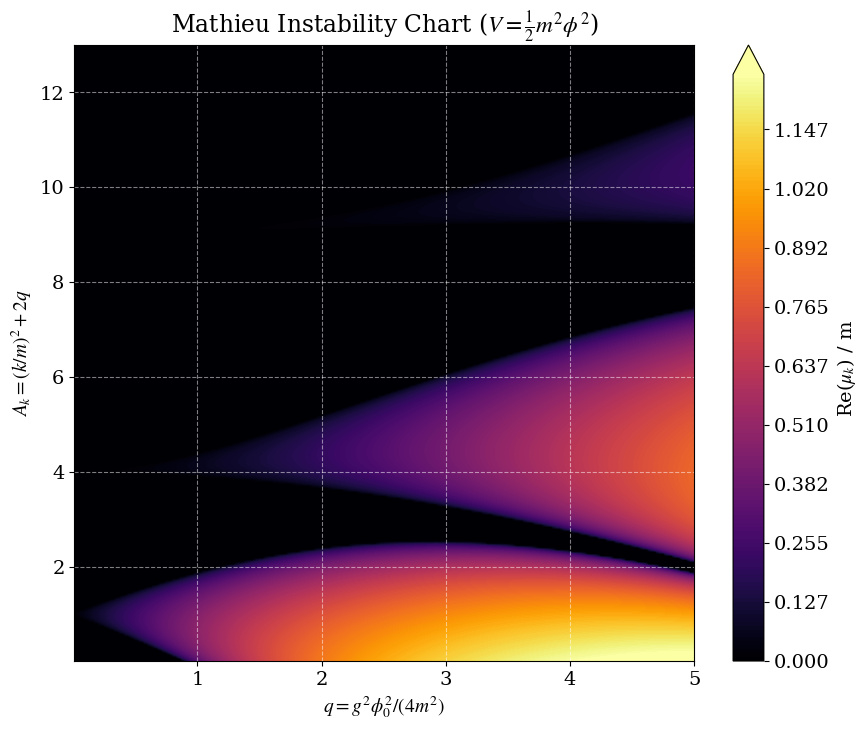

In [ ]:
n_points = 300
qs = np.linspace(0.01, 5, n_points)
Aks = np.linspace(0.01, 13, n_points)
q_mesh, Ak_mesh = np.meshgrid(qs, Aks)
mu_mesh = np.zeros_like(q_mesh, dtype=float)

for i in tqdm(range(len(Aks))):
    for j in range(len(qs)):
        mu_mesh[i, j] = mu_k(Aks[i], qs[j])

Plot saved as mathieu_instability_chart_canonical.png


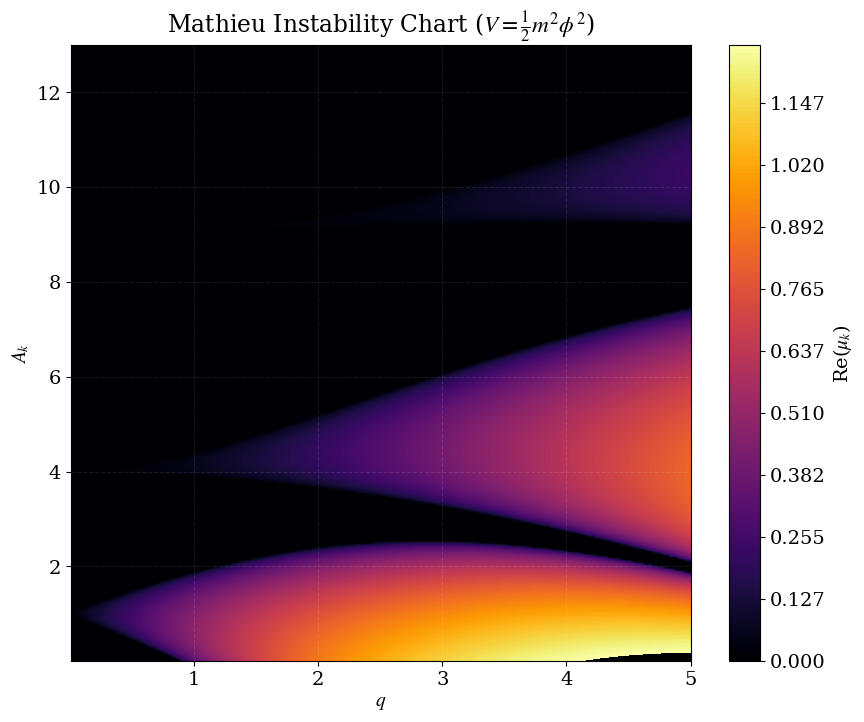

In [21]:

plt.figure()
max_mu = np.percentile(mu_mesh[mu_mesh > 0], 99.5) if np.any(mu_mesh > 0) else 1.0
cf = plt.contourf(q_mesh, Ak_mesh, mu_mesh, levels=np.linspace(0, max_mu, 150), cmap='inferno')
plt.colorbar(cf, label=r'Re($\mu_k$)')
plt.xlabel(r'$q$')
plt.ylabel(r'$A_k$')
plt.title(r'Mathieu Instability Chart ($V = \frac{1}{2} m^2 \phi^2$)')
plt.grid(True, linestyle='--', alpha=0.1, color='white')
plt.xlim(qs.min(), qs.max())
plt.ylim(Aks.min(), Aks.max())
plt.gca().set_facecolor('black')

# Save the figure
plt.savefig("mathieu_instability_chart_canonical.png", dpi=300, bbox_inches='tight', facecolor='white')
print("Plot saved as mathieu_instability_chart_canonical.png")

# Show the plot
plt.show()

## $\lambda \phi^4$

In [ ]:
lambda_phys = 1e-8 
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

# --- Function to Calculate Period Numerically ---
def calculate_period_phi4(lambda_p, phi0, phi_dot0, num_periods_to_avg=5):
    def background(t, y):
        phi, phi_dot = y
        phi_ddot = -lambda_p * phi**3
        return [phi_dot, phi_ddot]

    t_end_estimate = num_periods_to_avg * 10 * np.sqrt(1 / (lambda_p * phi0**2)) if phi0 > 1e-6 else 100
    t_span_period = (0, t_end_estimate)
    t_eval_period = np.linspace(t_span_period[0], t_span_period[1], 2000 * num_periods_to_avg)

    sol_period = solve_ivp(background, t_span_period, [phi0, phi_dot0], t_eval=t_eval_period, method='RK45', rtol=1e-8, atol=1e-10)

    if sol_period.status != 0:
        print(f"Warning: Period calculation integration failed. Status: {sol_period.status}")
        # Fallback to a rough estimate or raise an error
        return 10 * np.sqrt(1 / (lambda_p * phi0**2)) if phi0 > 1e-6 else np.inf


    phi_solution = sol_period.y[0]
    t_solution = sol_period.t

    peaks, _ = find_peaks(phi_solution, height=phi0*0.5)

    if len(peaks) < 2:
         neg_phi_solution = -phi_solution
         peaks, _ = find_peaks(neg_phi_solution, height=phi0*0.5)
         if len(peaks) < 2:
            print(f"Warning: Could not find enough peaks/troughs ({len(peaks)}) to determine period accurately for phi0={phi0}.")
            return 10 * np.sqrt(1 / (lambda_p * phi0**2)) if phi0 > 1e-6 else np.inf

    peak_times = t_solution[peaks]
    periods = np.diff(peak_times)

    if len(periods) == 0:
         print(f"Warning: Only one peak found. Cannot determine period.")
         return 10 * np.sqrt(1 / (lambda_p * phi0**2)) if phi0 > 1e-6 else np.inf


    Tosc_numerical = np.mean(periods)
    return Tosc_numerical

def calculate_mu_k_phi4(k_phys, g_phys, lambda_p, phi0, phi_dot0):
    """
    Calculates Floquet exponent mu_k by numerically integrating the background
    phi(t) and perturbation chi_k(t) for V = λ/4 φ⁴ potential.
    """
    # 1. Define the ODE system for V = λ/4 φ⁴
    def pert_phi4(t, y, k_physical, g_physical, lambda_physical):
        phi, phi_dot, chi_k, chi_dot_k = y
        # Background equation: ddot(phi) + λ phi³ = 0
        phi_ddot = -lambda_physical * phi**3
        # Perturbation equation: ddot(chi_k) + (k² + g² phi(t)²) chi_k = 0
        omega_sq = k_physical**2 + g_physical**2 * phi**2
        chi_ddot_k = -omega_sq * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

    # 2. Calculate the oscillation period NUMERICALLY
    Tosc = calculate_period_phi4(lambda_p, phi0, phi_dot0)
    if not np.isfinite(Tosc) or Tosc <= 1e-9: # Check for valid period
        # print(f"Warning: Invalid Tosc={Tosc} calculated for k={k_phys}, g={g_phys}. Skipping.")
        return 0.0 # Return stable if period calculation failed

    t_span = (0, Tosc)
    t_eval = [Tosc] # We only need the state at the end of one period

    # Integration precision
    rtol = 1e-8
    atol = 1e-10

    # --- Integrate for first initial condition [phi0, phi_dot0, 1, 0] ---
    y0_1 = [phi0, phi_dot0, 1.0, 0.0]
    sol1 = solve_ivp(pert_phi4, t_span, y0_1, t_eval=t_eval,
                     method='RK45', rtol=rtol, atol=atol, args=(k_phys, g_phys, lambda_p))
    if sol1.status != 0:
        # print(f"Warning: Integration 1 failed for k={k_phys}, g={g_phys}. Status: {sol1.status}")
        return 0.0
    y_final1 = sol1.y[:, -1]

    # --- Integrate for second initial condition [phi0, phi_dot0, 0, 1] ---
    y0_2 = [phi0, phi_dot0, 0.0, 1.0]
    sol2 = solve_ivp(pert_phi4, t_span, y0_2, t_eval=t_eval,
                     method='RK45', rtol=rtol, atol=atol, args=(k_phys, g_phys, lambda_p))
    if sol2.status != 0:
        # print(f"Warning: Integration 2 failed for k={k_phys}, g={g_phys}. Status: {sol2.status}")
        return 0.0
    y_final2 = sol2.y[:, -1]

    # --- Construct the Monodromy Matrix M for the chi_k subsystem ---
    M = np.array([
        [y_final1[2], y_final2[2]], # chi_k values
        [y_final1[3], y_final2[3]]  # chi_k_dot values
    ])

    # --- Calculate Floquet Exponent mu_k ---
    tr_M = np.trace(M)
    argument = tr_M / 2.0

    # Use complex arccosh to handle stability boundary
    mu_complex = np.arccosh(argument + 0j) / Tosc
    
    # Return the real part (instability growth rate)
    real_mu = np.real(mu_complex)
    return real_mu if real_mu > 1e-6 else 0.0 # Threshold noise

# --- Grid Setup (Using physical parameters k and g) ---
# Define ranges for k and g (adjust as needed based on expected resonance locations)
# These might need tuning depending on lambda_phys and phi0_initial
# It's often useful to scale k relative to some characteristic scale, e.g., sqrt(lambda)*phi0
k_scale = np.sqrt(lambda_phys) * phi0
k_phys_vals = np.linspace(0.01 * k_scale, 5.0 * k_scale, 30)
g_phys_vals = np.linspace(0.1, 200 * np.sqrt(lambda_phys), 30) # g range might need significant adjustment

k_mesh, g_mesh = np.meshgrid(k_phys_vals, g_phys_vals)
mu_mesh_phi4 = np.zeros_like(k_mesh, dtype=float)

# --- Calculation Loop ---
for i in tqdm(range(len(g_phys_vals))):
    for j in range(len(k_phys_vals)):
        mu_mesh_phi4[i, j] = calculate_mu_k_phi4(k_phys_vals[j], g_phys_vals[i], lambda_phys, phi0, phi_dot0)

plt.figure()

# Find a reasonable max value for colorbar, excluding potential outliers
max_mu = np.percentile(mu_mesh_phi4[mu_mesh_phi4 > 0], 99) if np.any(mu_mesh_phi4 > 0) else 1.0
cf = plt.contourf(g_mesh / np.sqrt(lambda_phys), k_mesh / k_scale, np.transpose(mu_mesh_phi4),
                  levels=np.linspace(0, max_mu, 100), cmap='inferno', extend='max')
plt.colorbar(cf, label=r'Re($\mu_k$)')
plt.xlabel(r'$k / (\sqrt{\lambda} \phi_0)$')
plt.ylabel(r'$g / \sqrt{\lambda}$')
plt.title(rf'Instability Chart for $V = \frac{{\lambda}}{{4}} \phi^4$')
plt.grid(True, linestyle='--', alpha=0.2)

plt.savefig("phi4_instability_chart.png", dpi=300, bbox_inches='tight')
print("Plot saved as phi4_instability_chart.png")

plt.show()

 37%|███▋      | 11/30 [1:31:29<2:47:44, 529.69s/it]

Integrating background for period calculation (up to t=1000000.00)...
Background calculated. Tosc = 74162.0810 (took 0.25s)
Interpolation function for phi^2(t) created.
Calculating Floquet exponents for 10x10 grid...


100%|██████████| 10/10 [29:32<00:00, 177.22s/it]


Generating plot...
Using vmax = 0.0000 for color normalization.
Plot saved as phi4_instability_chart_optimized.png
Total execution time: 1773.23 seconds


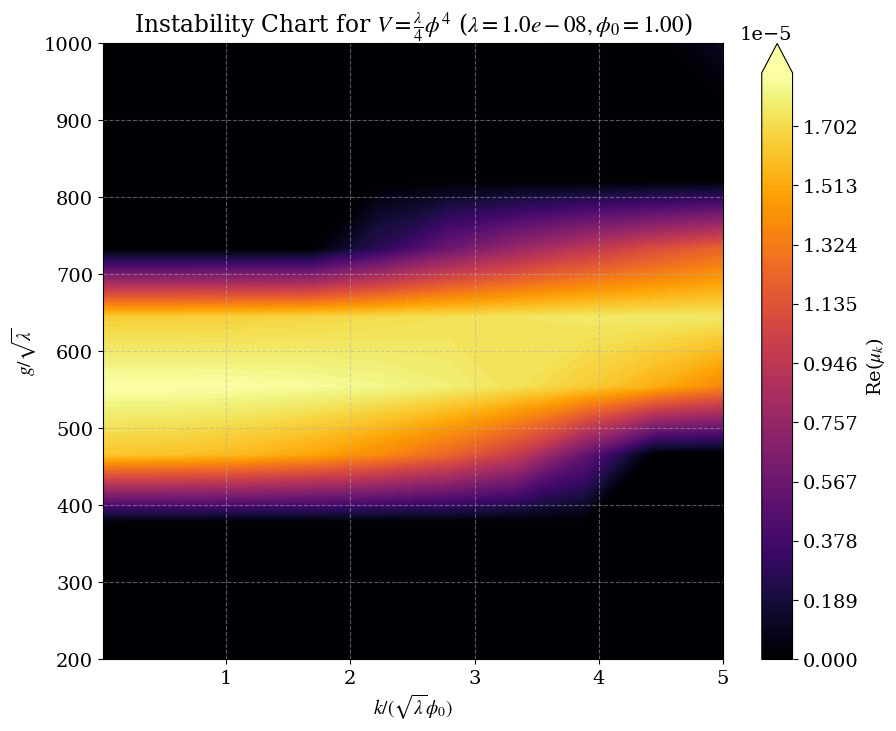

In [8]:
import os
import numpy as np
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.interpolate import interp1d # Import interpolation function
import matplotlib.colors as colors
import time # Para medir el tiempo

# --- Matplotlib Settings ---
mpl.rc('figure', figsize=(10, 8))
mpl.rc('text', usetex=False)
mpl.rc('font', family='serif')
mpl.rc('font', size='14')
mpl.rc('xtick', labelsize=14)
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

# --- Physical Parameters for V = λ/4 φ⁴ ---
lambda_phys = 1e-8
phi0_initial = 1.0
phi_dot0_initial = 0.0

# --- Function to Calculate Background and Period ONCE ---
def calculate_background_phi4(lambda_p, phi0, phi_dot0, num_periods_integrate=10, points_per_period=200):
    """
    Calculates the background phi(t) trajectory and oscillation period Tosc numerically.
    Returns Tosc, time array, and phi array.
    """
    start_time_period = time.time()
    def background_ode(t, y):
        phi, phi_dot = y
        phi_ddot = -lambda_p * phi**3
        return [phi_dot, phi_ddot]

    # Estimate rough period for integration time span
    t_end_estimate = num_periods_integrate * 10 * np.sqrt(1 / (lambda_p * phi0**2)) if phi0 > 1e-6 else 100
    t_span_period = (0, t_end_estimate)
    num_points = points_per_period * num_periods_integrate
    t_eval_period = np.linspace(t_span_period[0], t_span_period[1], num_points)

    print(f"Integrating background for period calculation (up to t={t_end_estimate:.2f})...")
    sol_period = solve_ivp(background_ode, t_span_period, [phi0, phi_dot0],
                           t_eval=t_eval_period, method='RK45', rtol=1e-9, atol=1e-11) # Higher precision for background

    if sol_period.status != 0:
        print(f"ERROR: Background integration failed. Status: {sol_period.status}")
        return None, None, None

    phi_solution = sol_period.y[0]
    t_solution = sol_period.t

    # Find peaks to determine period accurately
    peaks, _ = find_peaks(phi_solution, height=phi0*0.5)

    if len(peaks) < 2:
         neg_phi_solution = -phi_solution
         peaks, _ = find_peaks(neg_phi_solution, height=phi0*0.5)
         if len(peaks) < 2:
            print(f"Warning: Could not find enough peaks/troughs ({len(peaks)}) to determine period accurately.")
            return None, None, None # Indicate failure

    peak_times = t_solution[peaks]
    periods = np.diff(peak_times)

    if len(periods) == 0:
         print(f"Warning: Only one peak found. Cannot determine period.")
         return None, None, None

    Tosc_numerical = np.mean(periods)
    end_time_period = time.time()
    print(f"Background calculated. Tosc = {Tosc_numerical:.4f} (took {end_time_period - start_time_period:.2f}s)")
    return Tosc_numerical, t_solution, phi_solution

# --- Optimized Simulation Function for V = λ/4 φ⁴ ---
def calculate_mu_k_phi4_optimized(k_phys, g_phys, Tosc, phi_sq_interp_func):
    """
    Calculates Floquet exponent mu_k using precalculated background trajectory.
    `phi_sq_interp_func` is an interpolation function for phi(t)^2.
    """
    # 1. Define the SIMPLIFIED ODE system for chi_k only
    def pert_chi_ode(t, y, k_physical, g_physical, phi_sq_func):
        chi_k, chi_dot_k = y
        # Get phi^2 at time t using interpolation
        phi_squared = phi_sq_func(t)
        # Perturbation equation: ddot(chi_k) + (k² + g² phi(t)²) chi_k = 0
        omega_sq = k_physical**2 + g_physical**2 * phi_squared
        chi_ddot_k = -omega_sq * chi_k
        return [chi_dot_k, chi_ddot_k]

    # 2. Use the precalculated period
    if not np.isfinite(Tosc) or Tosc <= 1e-9:
        return 0.0

    t_span = (0, Tosc)
    t_eval = [Tosc]

    # Integration precision (can potentially be relaxed a bit vs background)
    rtol = 1e-8
    atol = 1e-10

    # --- Integrate for first initial condition [1, 0] ---
    y0_1 = [1.0, 0.0]
    # Pass the interpolation function as an argument
    sol1 = solve_ivp(pert_chi_ode, t_span, y0_1, t_eval=t_eval,
                     method='RK45', rtol=rtol, atol=atol, args=(k_phys, g_phys, phi_sq_interp_func))
    if sol1.status != 0:
        return 0.0
    y_final1 = sol1.y[:, -1]

    # --- Integrate for second initial condition [0, 1] ---
    y0_2 = [0.0, 1.0]
    sol2 = solve_ivp(pert_chi_ode, t_span, y0_2, t_eval=t_eval,
                     method='RK45', rtol=rtol, atol=atol, args=(k_phys, g_phys, phi_sq_interp_func))
    if sol2.status != 0:
        return 0.0
    y_final2 = sol2.y[:, -1]

    # --- Construct Monodromy Matrix M ---
    M = np.array([
        [y_final1[0], y_final2[0]],
        [y_final1[1], y_final2[1]]
    ])

    # --- Calculate Floquet Exponent mu_k ---
    tr_M = np.trace(M)
    argument = tr_M / 2.0
    mu_complex = np.arccosh(argument + 0j) / Tosc
    real_mu = np.real(mu_complex)
    return real_mu if real_mu > 1e-6 else 0.0

# --- Pre-calculation Step ---
start_time_total = time.time()
Tosc_global, t_bg, phi_bg = calculate_background_phi4(lambda_phys, phi0_initial, phi_dot0_initial)

if Tosc_global is None:
    print("ERROR: Failed to calculate background period. Exiting.")
    exit()

# Create interpolation function for phi^2(t) over the necessary range [0, Tosc_global]
# We need to ensure our precalculated arrays cover at least one full period accurately.
# Let's find the index corresponding to the first full period
first_period_index = np.searchsorted(t_bg, Tosc_global) + 1 # +1 to include the endpoint slightly beyond Tosc
t_interp = t_bg[:first_period_index]
phi_sq_interp = phi_bg[:first_period_index]**2

# Use linear interpolation (fast), kind='cubic' is smoother but slower
phi_sq_interpolator = interp1d(t_interp, phi_sq_interp, kind='linear', bounds_error=False, fill_value="extrapolate")
print("Interpolation function for phi^2(t) created.")

# --- Grid Setup ---
n_points_k = 10 # Reducido para prueba rápida, aumenta a 150 o más luego
n_points_g = 10 # Reducido para prueba rápida
k_scale = np.sqrt(lambda_phys) * phi0_initial
k_phys_vals = np.linspace(0.01 * k_scale, 5.0 * k_scale, n_points_k)
g_phys_vals = np.linspace(0.1, 200 * np.sqrt(lambda_phys), n_points_g)

k_mesh, g_mesh = np.meshgrid(k_phys_vals, g_phys_vals)
mu_mesh_phi4 = np.zeros_like(k_mesh, dtype=float)

# --- Calculation Loop (Optimized) ---
print(f"Calculating Floquet exponents for {n_points_k}x{n_points_g} grid...")
for i in tqdm(range(len(g_phys_vals))):
    for j in range(len(k_phys_vals)):
        # Pass Tosc_global and the interpolator
        mu_mesh_phi4[i, j] = calculate_mu_k_phi4_optimized(k_phys_vals[j], g_phys_vals[i],
                                                           Tosc_global, phi_sq_interpolator)

# --- Plotting ---
print("Generating plot...")
plt.figure()

max_mu = np.percentile(mu_mesh_phi4[mu_mesh_phi4 > 0], 99.5) if np.any(mu_mesh_phi4 > 0) else 1.0
print(f"Using vmax = {max_mu:.4f} for color normalization.")
norm = colors.Normalize(vmin=0, vmax=max_mu)

# Transpose mu_mesh_phi4 because contourf expects Z[row, col] -> Z[iy, ix]
# Our loops fill it as Z[ig, ik] corresponding to Y=g, X=k
cf = plt.contourf(k_mesh / k_scale, g_mesh / np.sqrt(lambda_phys), mu_mesh_phi4,
                  levels=np.linspace(0, max_mu, 100), cmap='inferno', norm=norm, extend='max')

plt.colorbar(cf, label=r'Re($\mu_k$)') # Raw exponent
plt.xlabel(r'$k / (\sqrt{\lambda} \phi_0)$')
plt.ylabel(r'$g / \sqrt{\lambda}$')
plt.title(rf'Instability Chart for $V = \frac{{\lambda}}{{4}} \phi^4$ ($\lambda={lambda_phys:.1e}, \phi_0={phi0_initial:.2f}$)')
plt.grid(True, linestyle='--', alpha=0.5)

# Save the figure
plt.savefig("phi4_instability_chart_optimized.png", dpi=300, bbox_inches='tight')
print("Plot saved as phi4_instability_chart_optimized.png")

end_time_total = time.time()
print(f"Total execution time: {end_time_total - start_time_total:.2f} seconds")

plt.show()

In [ ]:
import numpy as np
from scipy.integrate import quad

# --- 1. Definir las Constantes (EJEMPLO) ---
# (Estos son los valores que vos tenés que definir)
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
E = 1/2 * phi_dot0**2 + phi0**2


# --- 2. Definir el Potencial V(phi) ---
# ¡ESTE ES EL PASO MÁS IMPORTANTE!
# Tenés que reemplazar esta función con tu potencial real.
# Debe ser una función de 'phi' y puede usar las constantes E y phi_0.
#
# Ejemplo: V(phi) = E * (phi / phi_0)^2
def V(phi, E_val, phi_0_val):
    """
    Define el potencial V(phi).
    Pasamos E y phi_0 como argumentos (E_val, phi_0_val)
    para que la función no dependa de variables globales.
    """
    return E_val * (phi / phi_0_val)**2


# --- 3. Definir el Integrando f(phi) ---
# Esta es la función completa que va dentro de la integral
def integrand(phi, E_val, phi_0_val):
    """
    Es f(phi) = 1 / sqrt(1 - V(phi)/E)
    """
    v_phi = V(phi, E_val, phi_0_val)
    
    # Manejo de precisión:
    # Teóricamente, V(phi) <= E. 
    # Numéricamente, V(phi)/E podría ser 1.00000000001 y dar error.
    # Con np.clip, nos aseguramos que el ratio nunca sea > 1.
    ratio = np.clip(v_phi / E_val, -np.inf, 0.999999999999)

    return 1.0 / np.sqrt(1.0 - ratio)


# --- 4. Calcular la Integral con scipy.integrate.quad ---

# Límites de integración
limite_inferior = -phi0
limite_superior = phi0

# Argumentos extra para pasar a la función 'integrand' (E y phi_0)
argumentos = (E, phi0)

# ¡Cuidado! La función explota (tiende a infinito) en los límites,
# porque V(phi_0) = E, y el denominador se hace 0.
# Le "avisamos" a quad() sobre estas singularidades con el
# argumento 'points' para que las maneje correctamente.
puntos_singulares = [limite_inferior, limite_superior]

# quad() devuelve (resultado_de_la_integral, error_estimado)
integral_result, error = quad(
    integrand,
    limite_inferior,
    limite_superior,
    args=argumentos,
    points=puntos_singulares
)

# --- 5. Calcular el Resultado Final T ---
pre_factor = 1.0 / np.sqrt(2.0 * E)
T_numerical = pre_factor * integral_result

# --- 6. Mostrar Resultados ---
print("--- Cálculo Numérico de la Integral ---")
print(f"Parámetros: E = {E}, phi_0 = {phi0}")
print(f"Potencial de ejemplo: V(phi) = E * (phi/phi_0)^2\n")

print(f"Valor de la integral: {integral_result:.8f}")
print(f"Error estimado:       {error:.2e}")
print(f"Factor 1/sqrt(2E):    {pre_factor:.8f}\n")
print(f"Resultado final T =   {T_numerical:.8f}")


# --- Verificación (Solo para este V(phi) de ejemplo) ---
# Para este potencial, la integral se puede resolver analíticamente
# y da exactamente (pi * phi_0).
T_analytical = (1.0 / np.sqrt(2.0 * E)) * (np.pi * phi0)
print(f"Resultado analítico (para este V): {T_analytical:.8f}")
print(f"Coinciden: {np.isclose(T_numerical, T_analytical)}")